170 170
-0.7682581290479574
0.023226336694633067
-2.959054528951416
0.03968501024156722
7.875793734807225
0.08575188652120339
6.261826343367593
0.09278775474803473
0.34184200646454144 1.0081581384813791


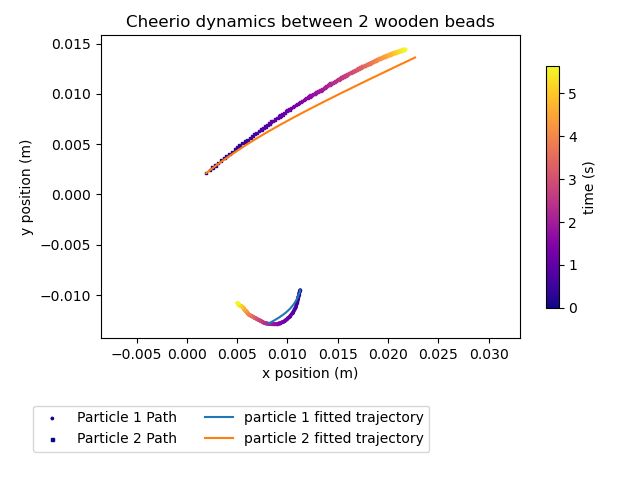

[0.    0.033 0.067 0.1   0.134 0.167 0.201 0.234 0.267 0.301 0.334 0.368
 0.401 0.435 0.468 0.501 0.535 0.568 0.602 0.635] [0.001917 0.00227  0.002564 0.002832 0.003108 0.003386 0.003727 0.003947
 0.004216 0.004508 0.004792 0.005017 0.005233 0.00551  0.005829 0.00603
 0.006304 0.006503 0.006711 0.006903]


In [190]:
#RQ3 home strech

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution
%matplotlib widget
matrix = np.loadtxt(
    "DATA VIDEO RQ 2 A.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
  
N_0=0
t_data1 = matrix[:-28, 0][N_0:-1]
x_data1 = matrix[:-28, 1][N_0:-1]
y_data1 = matrix[:-28, 2][N_0:-1]

plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
plt.colorbar(sc1,label='time (s)', shrink=0.8)
matrix = np.loadtxt(
    "DATA VIDEO RQ 2 B.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.')))
t_data2 = matrix[:-28, 0][N_0:-1]
x_data2 = matrix[:-28, 1][N_0:-1]
y_data2 = matrix[:-28, 2][N_0:-1]
sc2 = plt.scatter(x_data2, y_data2, marker='s', c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y position (m)')
plt.xlabel('x position (m)')
plt.axis('equal')
print(len(t_data1),len(t_data2))
Lc = 2.7 * 10 ** (-3)
#initial position
x_sim1_0, y_sim1_0=x_data1[0], y_data1[0]
x_sim2_0, y_sim2_0=x_data2[0], y_data2[0]
dt=t_data1[1]-t_data1[0]
#intial velocity

N_1=20

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], x_data1[:N_1], 1,cov=True)
vx_sim1_0=p_gues[0]
vx_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim1_0*1000)
print(vx_sim1_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], y_data1[:N_1], 1,cov=True)
vy_sim1_0=p_gues[0]
vy_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim1_0*1000)
print(vy_sim1_0_error*1000)

N_2=20

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], x_data2[:N_2], 1,cov=True)
vx_sim2_0=p_gues[0]
vx_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim2_0*1000)
print(vx_sim2_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], y_data2[:N_2], 1,cov=True)
vy_sim2_0=p_gues[0]
vy_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim2_0*1000)
print(vy_sim2_0_error*1000)
def cheerios_fit(params):
    A,B = params
    t = np.arange(0, t_data1[-1]+dt/2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0]=x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0]=x_sim1_0, y_sim1_0
    vx1=vx_sim1_0
    vy1=vy_sim1_0
    vx2=vx_sim2_0
    vy2=vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error =(np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2)) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error

global_bounds=((0,2),(0,10))
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
    )
fitted_params = result.x
params = fitted_params
A,B=params

def cheerios_plot(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    end_index=len(t)
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r<0.01:
            end_index=i+1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index],y_sim2[:end_index]
plt.title("Cheerio dynamics between 2 wooden beads")
x1,y1,x2,y2=cheerios_plot(params)
plt.plot(x1,y1,label='particle 1 fitted trajectory')
plt.plot(x2,y2,label='particle 2 fitted trajectory')
plt.legend(ncols=2,bbox_to_anchor=(0.8,-0.2))
print(A,B)
plt.tight_layout()
plt.show()
print(t_data2[:N_2], x_data2[:N_2])

4.928
134 134
-0.31175433544018305
0.027848363473802006
-1.0266978563259488
0.04182729263015596
3.1392723642879483
0.04338967475673475
0.8511830223860092
0.03843485918541928
0.13019081922835166 0.46216158055559875


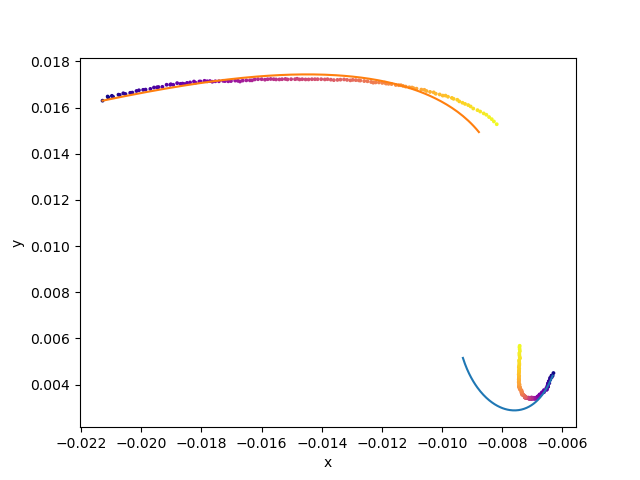

[0.335 0.369 0.402 0.436 0.469 0.503 0.536 0.57  0.603 0.637 0.67  0.704
 0.738 0.771 0.805 0.838 0.872 0.905 0.939 0.972] [-0.02129 -0.02112 -0.0211  -0.02098 -0.02094 -0.02076 -0.02072 -0.0206
 -0.02053 -0.02037 -0.0203  -0.02016 -0.02008 -0.01994 -0.01986 -0.0197
 -0.01958 -0.01948 -0.01943 -0.0193 ]
4.794


In [191]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution
%matplotlib widget
matrix = np.loadtxt(
    "DATA VIDEO RQ 3 A.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
  
N_0=10
t_data1 = matrix[:-28, 0]
x_data1 = matrix[:-28, 1][N_0:-4]
y_data1 = matrix[:-28, 2][N_0:-4]
print(t_data1[-1])
t_data1=t_data1[N_0:-4]
plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
matrix = np.loadtxt(
    "DATA VIDEO RQ 3 B.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.')))
t_data2 = matrix[:-28, 0][N_0:-4]
x_data2 = matrix[:-28, 1][N_0:-4]
y_data2 = matrix[:-28, 2][N_0:-4]
sc2 = plt.scatter(x_data2, y_data2, c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y')
plt.xlabel('x')
print(len(t_data1),len(t_data2))
Lc = 2.7 * 10 ** (-3)
#initial position
x_sim1_0, y_sim1_0=x_data1[0], y_data1[0]
x_sim2_0, y_sim2_0=x_data2[0], y_data2[0]
dt=t_data1[1]-t_data1[0]
#intial velocity

N_1=20

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], x_data1[:N_1], 1,cov=True)
vx_sim1_0=p_gues[0]
vx_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim1_0*1000)
print(vx_sim1_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], y_data1[:N_1], 1,cov=True)
vy_sim1_0=p_gues[0]
vy_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim1_0*1000)
print(vy_sim1_0_error*1000)

N_2=20

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], x_data2[:N_2], 1,cov=True)
vx_sim2_0=p_gues[0]
vx_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim2_0*1000)
print(vx_sim2_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], y_data2[:N_2], 1,cov=True)
vy_sim2_0=p_gues[0]
vy_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim2_0*1000)
print(vy_sim2_0_error*1000)
def cheerios_fit(params):
    A,B = params
    t = np.arange(0, t_data1[-1]+dt/2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0]=x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0]=x_sim1_0, y_sim1_0
    vx1=vx_sim1_0
    vy1=vy_sim1_0
    vx2=vx_sim2_0
    vy2=vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error =(np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2)) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error

global_bounds=((0,10),(0,10))
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
    )
fitted_params = result.x
params = fitted_params
A,B=params

def cheerios_plot(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    end_index=len(t)
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r<0.01:
            end_index=i+1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index],y_sim2[:end_index]

x1,y1,x2,y2=cheerios_plot(params)
plt.plot(x1,y1)
plt.plot(x2,y2)
print(A,B)
plt.show()
print(t_data2[:N_2], x_data2[:N_2])
print(t_data1[-1])

32.332
956 947
0.3377926638232638
0.04704447898688199
-0.631299972635676
0.05179276409711064
3.9679804119559106
0.062354236278991115
5.173932258047957
0.04602617253605591


RuntimeError: The map-like callable must be of the form f(func, iterable), returning a sequence of numbers the same length as 'iterable'

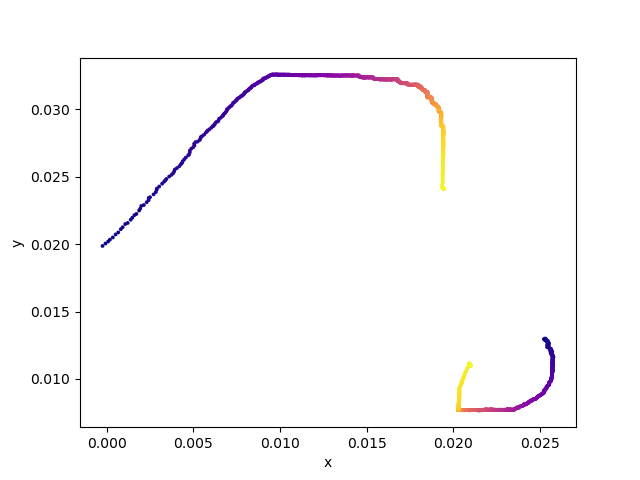

In [125]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution
%matplotlib widget
matrix = np.loadtxt(
    "DATA VIDEO RQ 4 A.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
  
N_0=10
t_data1 = matrix[:-28, 0]
x_data1 = matrix[:-28, 1][N_0:-4]
y_data1 = matrix[:-28, 2][N_0:-4]
print(t_data1[-1])
t_data1=t_data1[N_0:-4]
plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
matrix = np.loadtxt(
    "DATA VIDEO RQ 4 B.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.')))
t_data2 = matrix[:-28, 0][N_0:-4]
x_data2 = matrix[:-28, 1][N_0:-4]
y_data2 = matrix[:-28, 2][N_0:-4]
sc2 = plt.scatter(x_data2, y_data2, c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y')
plt.xlabel('x')
print(len(t_data1),len(t_data2))
Lc = 2.7 * 10 ** (-3)
#initial position
x_sim1_0, y_sim1_0=x_data1[0], y_data1[0]
x_sim2_0, y_sim2_0=x_data2[0], y_data2[0]
dt=t_data1[1]-t_data1[0]
#intial velocity

N_1=20

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], x_data1[:N_1], 1,cov=True)
vx_sim1_0=p_gues[0]
vx_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim1_0*1000)
print(vx_sim1_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], y_data1[:N_1], 1,cov=True)
vy_sim1_0=p_gues[0]
vy_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim1_0*1000)
print(vy_sim1_0_error*1000)

N_2=20

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], x_data2[:N_2], 1,cov=True)
vx_sim2_0=p_gues[0]
vx_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim2_0*1000)
print(vx_sim2_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], y_data2[:N_2], 1,cov=True)
vy_sim2_0=p_gues[0]
vy_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim2_0*1000)
print(vy_sim2_0_error*1000)
def cheerios_fit(params):
    A,B = params
    t = np.arange(0, t_data1[-1]+dt/2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0]=x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0]=x_sim1_0, y_sim1_0
    vx1=vx_sim1_0
    vy1=vy_sim1_0
    vx2=vx_sim2_0
    vy2=vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error =(np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2)) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error

global_bounds=((0,10),(0,10))
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
    )
fitted_params = result.x
params = fitted_params
A,B=params

def cheerios_plot(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    end_index=len(t)
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r<0.01:
            end_index=i+1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index],y_sim2[:end_index]

x1,y1,x2,y2=cheerios_plot(params)
plt.plot(x1,y1)
plt.plot(x2,y2)
print(A,B)
plt.show()
print(t_data2[:N_2], x_data2[:N_2])
print(t_data1[-1])

8.797
210 210
-0.01226157827586567
0.01262238501846084
-2.067366377294745
0.012182249846286306
0.5117849884936415
0.035671119383215925
-0.019552108415054628
0.010965742000804139
0.16821325854788285 0.2822600122169512


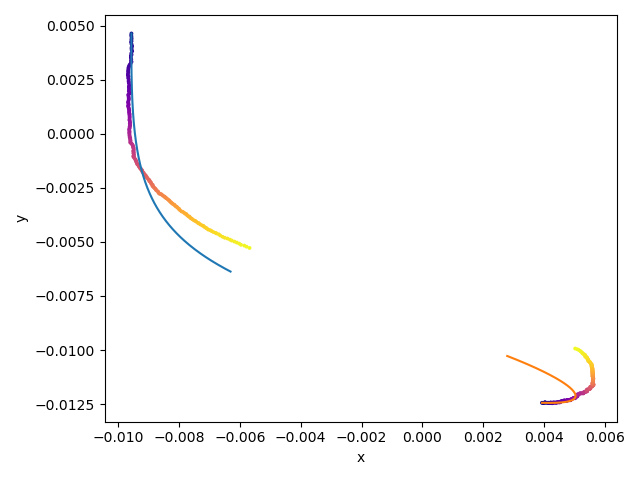

[1.672 1.706 1.739 1.773 1.806 1.84  1.873 1.907 1.94  1.973 2.007 2.04
 2.074 2.107 2.141 2.174 2.208 2.241 2.274 2.308] [0.003937 0.003966 0.003998 0.00403  0.004035 0.004053 0.00408  0.004131
 0.004132 0.004155 0.004167 0.004214 0.004231 0.004237 0.004246 0.004222
 0.004237 0.004239 0.004242 0.004259]
8.663


In [192]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution
%matplotlib widget
matrix = np.loadtxt(
    "DATA VIDEO RQ 5 A.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
  
N_0=50
t_data1 = matrix[:-28, 0]
x_data1 = matrix[:-28, 1][N_0:-4]
y_data1 = matrix[:-28, 2][N_0:-4]
print(t_data1[-1])
t_data1=t_data1[N_0:-4]
plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
matrix = np.loadtxt(
    "DATA VIDEO RQ 5 B.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.')))
t_data2 = matrix[:-28, 0][N_0:-4]
x_data2 = matrix[:-28, 1][N_0:-4]
y_data2 = matrix[:-28, 2][N_0:-4]
sc2 = plt.scatter(x_data2, y_data2, c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y')
plt.xlabel('x')
print(len(t_data1),len(t_data2))
Lc = 2.7 * 10 ** (-3)
#initial position
x_sim1_0, y_sim1_0=x_data1[0], y_data1[0]
x_sim2_0, y_sim2_0=x_data2[0], y_data2[0]
dt=t_data1[1]-t_data1[0]
#intial velocity

N_1=20

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], x_data1[:N_1], 1,cov=True)
vx_sim1_0=p_gues[0]
vx_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim1_0*1000)
print(vx_sim1_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], y_data1[:N_1], 1,cov=True)
vy_sim1_0=p_gues[0]
vy_sim1_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim1_0*1000)
print(vy_sim1_0_error*1000)

N_2=20

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], x_data2[:N_2], 1,cov=True)
vx_sim2_0=p_gues[0]
vx_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim2_0*1000)
print(vx_sim2_0_error*1000)

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], y_data2[:N_2], 1,cov=True)
vy_sim2_0=p_gues[0]
vy_sim2_0_error=np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim2_0*1000)
print(vy_sim2_0_error*1000)
def cheerios_fit(params):
    A,B = params
    t = np.arange(0, t_data1[-1]+dt/2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0]=x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0]=x_sim1_0, y_sim1_0
    vx1=vx_sim1_0
    vy1=vy_sim1_0
    vx2=vx_sim2_0
    vy2=vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error =(np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2)) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error

global_bounds=((0,10),(0,10))
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
    )
fitted_params = result.x
params = fitted_params
A,B=params

def cheerios_plot(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    end_index=len(t)
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r<0.01:
            end_index=i+1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index],y_sim2[:end_index]

x1,y1,x2,y2=cheerios_plot(params)
plt.plot(x1,y1)
plt.plot(x2,y2)
print(A,B)
plt.tight_layout()
plt.show()
print(t_data2[:N_2], x_data2[:N_2])
print(t_data1[-1])

4.928
134 134
-0.31175433544018305
0.027848363473802006
-1.0266978563259488
0.04182729263015596
3.1392723642879483
0.04338967475673475
0.8511830223860092
0.03843485918541928
[0.335 0.369 0.402 0.436 0.469 0.503 0.536 0.57  0.603 0.637 0.67  0.704
 0.738 0.771 0.805 0.838 0.872 0.905 0.939 0.972] [-0.02129 -0.02112 -0.0211  -0.02098 -0.02094 -0.02076 -0.02072 -0.0206
 -0.02053 -0.02037 -0.0203  -0.02016 -0.02008 -0.01994 -0.01986 -0.0197
 -0.01958 -0.01948 -0.01943 -0.0193 ]
0.12994113292825735 0.46267975223068897


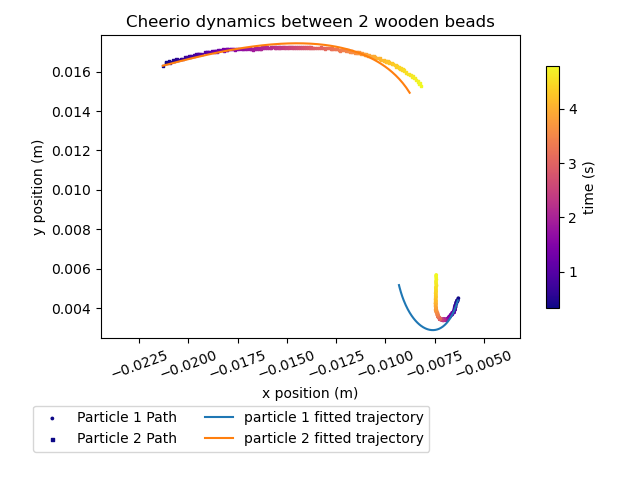

In [193]:
#RQ3 home strech

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution
%matplotlib widget

matrix = np.loadtxt(
    "DATA VIDEO RQ 3 A.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
  
N_0 = 10
t_data1 = matrix[:-28, 0]
x_data1 = matrix[:-28, 1][N_0:-4]
y_data1 = matrix[:-28, 2][N_0:-4]
print(t_data1[-1])
t_data1 = t_data1[N_0:-4]

plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
plt.colorbar(sc1, label='time (s)', shrink=0.8)

matrix = np.loadtxt(
    "DATA VIDEO RQ 3 B.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
t_data2 = matrix[:-28, 0][N_0:-4]
x_data2 = matrix[:-28, 1][N_0:-4]
y_data2 = matrix[:-28, 2][N_0:-4]
sc2 = plt.scatter(x_data2, y_data2, marker='s', c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")

plt.ylabel('y position (m)')
plt.xlabel('x position (m)')
plt.axis('equal')
print(len(t_data1), len(t_data2))

Lc = 2.7 * 10 ** (-3)
x_sim1_0, y_sim1_0 = x_data1[0], y_data1[0]
x_sim2_0, y_sim2_0 = x_data2[0], y_data2[0]
dt = t_data1[1] - t_data1[0]

N_1 = 20

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], x_data1[:N_1], 1, cov=True)
vx_sim1_0 = p_gues[0]
vx_sim1_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim1_0 * 1000)
print(vx_sim1_0_error * 1000)

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], y_data1[:N_1], 1, cov=True)
vy_sim1_0 = p_gues[0]
vy_sim1_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim1_0 * 1000)
print(vy_sim1_0_error * 1000)

N_2 = 20

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], x_data2[:N_2], 1, cov=True)
vx_sim2_0 = p_gues[0]
vx_sim2_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim2_0 * 1000)
print(vx_sim2_0_error * 1000)

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], y_data2[:N_2], 1, cov=True)
vy_sim2_0 = p_gues[0]
vy_sim2_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim2_0 * 1000)
print(vy_sim2_0_error * 1000)

print(t_data2[:N_2], x_data2[:N_2])


def cheerios_fit(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error = (np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2)) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error


global_bounds = ((0, 10), (0, 10))
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
)
fitted_params = result.x
params = fitted_params
A, B = params


def cheerios_plot(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    end_index = len(t)
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r < 0.01:
            end_index = i + 1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index], y_sim2[:end_index]


plt.title("Cheerio dynamics between 2 wooden beads")
x1, y1, x2, y2 = cheerios_plot(params)
plt.plot(x1, y1, label='particle 1 fitted trajectory')
plt.plot(x2, y2, label='particle 2 fitted trajectory')
plt.legend(ncols=2, bbox_to_anchor=(0.8, -0.2))
print(A, B)
plt.xticks(rotation=20) 
plt.tight_layout()
plt.show()


8.797
210 210
-0.01226157827586567
0.01262238501846084
-2.067366377294745
0.012182249846286306
0.5117849884936415
0.035671119383215925
-0.019552108415054628
0.010965742000804139
0.1682500495570842 0.2823392277857224


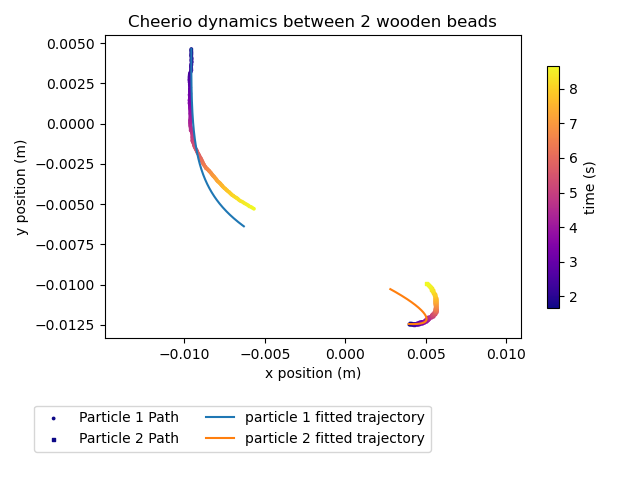

[1.672 1.706 1.739 1.773 1.806 1.84  1.873 1.907 1.94  1.973 2.007 2.04
 2.074 2.107 2.141 2.174 2.208 2.241 2.274 2.308] [0.003937 0.003966 0.003998 0.00403  0.004035 0.004053 0.00408  0.004131
 0.004132 0.004155 0.004167 0.004214 0.004231 0.004237 0.004246 0.004222
 0.004237 0.004239 0.004242 0.004259]
8.663


In [196]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import differential_evolution
from scipy.optimize import curve_fit
%matplotlib widget

matrix = np.loadtxt(
    "DATA VIDEO RQ 5 A.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
  
N_0 = 50
t_data1 = matrix[:-28, 0]
x_data1 = matrix[:-28, 1][N_0:-4]
y_data1 = matrix[:-28, 2][N_0:-4]
print(t_data1[-1])
t_data1 = t_data1[N_0:-4]

plt.close('all')
sc1 = plt.scatter(x_data1, y_data1, c=t_data1, cmap='plasma', s=3, label="Particle 1 Path")
plt.colorbar(sc1, label='time (s)', shrink=0.8)

matrix = np.loadtxt(
    "DATA VIDEO RQ 5 B.txt",
    skiprows=2,
    converters=lambda s: float(s.replace(',', '.'))
)
t_data2 = matrix[:-28, 0][N_0:-4]
x_data2 = matrix[:-28, 1][N_0:-4]
y_data2 = matrix[:-28, 2][N_0:-4]
sc2 = plt.scatter(x_data2, y_data2, marker='s', c=t_data2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y position (m)')
plt.xlabel('x position (m)')
plt.axis('equal')
print(len(t_data1), len(t_data2))

Lc = 2.7 * 10 ** (-3)
x_sim1_0, y_sim1_0 = x_data1[0], y_data1[0]
x_sim2_0, y_sim2_0 = x_data2[0], y_data2[0]
dt = t_data1[1] - t_data1[0]

N_1 = 20

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], x_data1[:N_1], 1, cov=True)
vx_sim1_0 = p_gues[0]
vx_sim1_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim1_0 * 1000)
print(vx_sim1_0_error * 1000)

p_gues, cov_matrix = np.polyfit(t_data1[:N_1], y_data1[:N_1], 1, cov=True)
vy_sim1_0 = p_gues[0]
vy_sim1_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim1_0 * 1000)
print(vy_sim1_0_error * 1000)

N_2 = 20

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], x_data2[:N_2], 1, cov=True)
vx_sim2_0 = p_gues[0]
vx_sim2_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vx_sim2_0 * 1000)
print(vx_sim2_0_error * 1000)

p_gues, cov_matrix = np.polyfit(t_data2[:N_2], y_data2[:N_2], 1, cov=True)
vy_sim2_0 = p_gues[0]
vy_sim2_0_error = np.sqrt(np.diag(cov_matrix))[0]
print(vy_sim2_0 * 1000)
print(vy_sim2_0_error * 1000)


def cheerios_fit(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t_data1))
    y_sim1 = np.zeros(len(t_data1))
    x_sim2 = np.zeros(len(t_data1))
    y_sim2 = np.zeros(len(t_data1))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    for i in range(len(t_data1) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
    error = (np.sum((x_data1 - x_sim1) ** 2) + np.sum((y_data1 - y_sim1) ** 2)) + np.sum(
        (x_data2 - x_sim2) ** 2) + np.sum((y_data2 - y_sim2) ** 2)
    return error


global_bounds = ((0, 10), (0, 10))
result = differential_evolution(
    cheerios_fit,
    bounds=global_bounds
)
fitted_params = result.x
params = fitted_params
A, B = params


def cheerios_plot(params):
    A, B = params
    t = np.arange(0, t_data1[-1] + dt / 2, dt)
    x_sim1 = np.zeros(len(t))
    y_sim1 = np.zeros(len(t))
    x_sim2 = np.zeros(len(t))
    y_sim2 = np.zeros(len(t))
    x_sim2[0], y_sim2[0] = x_sim2_0, y_sim2_0
    x_sim1[0], y_sim1[0] = x_sim1_0, y_sim1_0
    vx1 = vx_sim1_0
    vy1 = vy_sim1_0
    vx2 = vx_sim2_0
    vy2 = vy_sim2_0
    end_index = len(t)
    for i in range(len(t) - 1):
        r = np.sqrt((x_sim1[i] - x_sim2[i]) ** 2 + (y_sim1[i] - y_sim2[i]) ** 2)
        Attract = B * k1(r / Lc)

        ax2 = -A * vx2 + Attract * (x_sim1[i] - x_sim2[i]) / r
        ay2 = -A * vy2 + Attract * (y_sim1[i] - y_sim2[i]) / r
        ax1 = -A * vx1 - Attract * (x_sim1[i] - x_sim2[i]) / r
        ay1 = -A * vy1 - Attract * (y_sim1[i] - y_sim2[i]) / r
        vx2 = vx2 + ax2 * dt
        vy2 = vy2 + ay2 * dt
        vx1 = vx1 + ax1 * dt
        vy1 = vy1 + ay1 * dt

        x_sim2[i + 1] = x_sim2[i] + vx2 * dt
        y_sim2[i + 1] = y_sim2[i] + vy2 * dt
        x_sim1[i + 1] = x_sim1[i] + vx1 * dt
        y_sim1[i + 1] = y_sim1[i] + vy1 * dt
        if r < 0.01:
            end_index = i + 1
            break

    return x_sim1[:end_index], y_sim1[:end_index], x_sim2[:end_index], y_sim2[:end_index]


plt.title("Cheerio dynamics between 2 wooden beads")
x1, y1, x2, y2 = cheerios_plot(params)
plt.plot(x1, y1, label='particle 1 fitted trajectory')
plt.plot(x2, y2, label='particle 2 fitted trajectory')
plt.legend(ncols=2, bbox_to_anchor=(0.8, -0.2))
print(A, B)
plt.tight_layout()
plt.show()
print(t_data2[:N_2], x_data2[:N_2])
print(t_data1[-1])